In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
dfs

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.456468,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849


In [2]:
# import numpy as np

# # Keep features with variance above a threshold
# variance_threshold = 0.09
# dfs = dfs.loc[:, dfs.var() > variance_threshold]

In [3]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
time_series_data = np.nan_to_num(X, nan=0.0)[:,:,:]
Y = np.nan_to_num(y, nan=0.0)[:,:,1:-1]
print("Shape:", time_series_data.shape, Y.shape)  

Shape: (100, 1743, 17) (100, 47, 4)


In [4]:
from utils.clustering_utils import cluster_time_series_subsequences, plot_k_selection, cluster_time_series_subsequences_ssts

/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


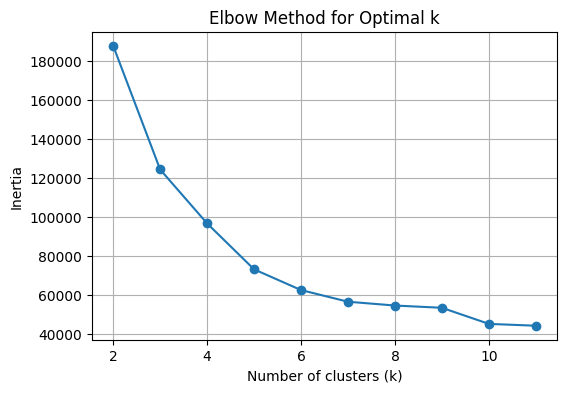

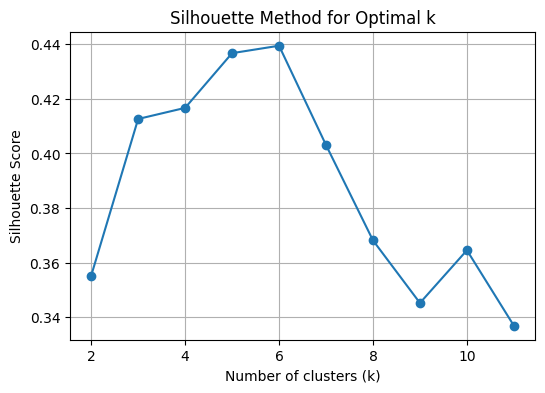

In [5]:
inertias, scores = plot_k_selection(time_series_data, series_idx=50, window_size=10, k_range=range(2, 12))

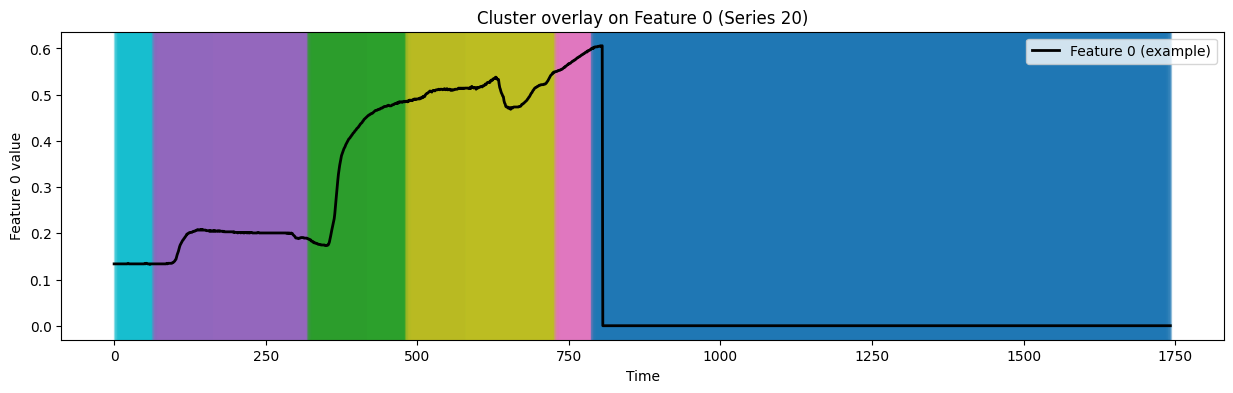

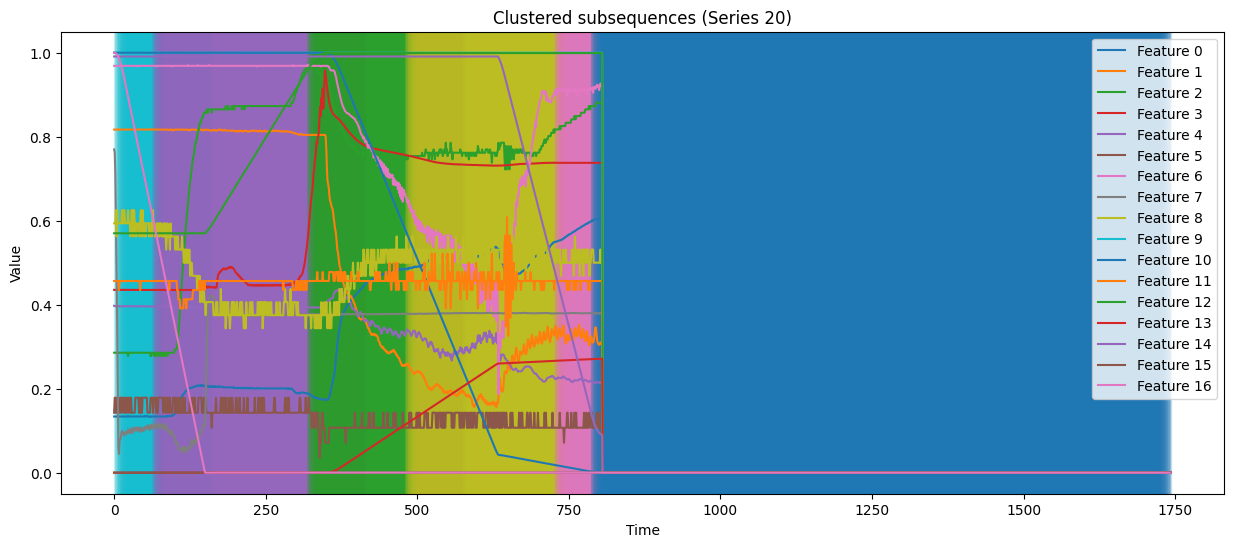

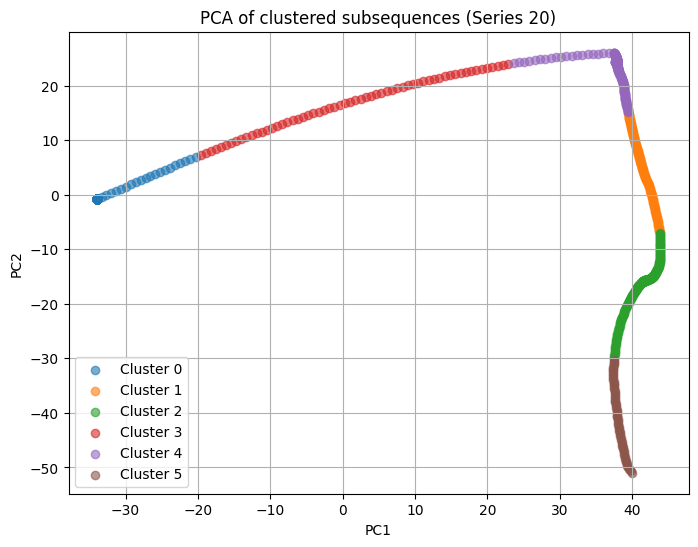

,Unnamed: 0,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
920,1748,40,0.000000,0.395551,0.486421,0.495174,0.466590
921,1749,40,0.022036,0.386089,0.475024,0.504063,0.454447
922,1750,40,0.044072,0.381731,0.471326,0.506576,0.450507
923,1751,40,0.066108,0.372881,0.472895,0.502423,0.452179
924,1752,40,0.088145,0.361444,0.482698,0.489131,0.462624
925,1753,40,0.110181,0.343594,0.495774,0.470653,0.476556
926,1754,40,0.132217,0.331599,0.503059,0.459767,0.484318
927,1755,40,0.154253,0.326296,0.498444,0.462943,0.479401
928,1756,40,0.176289,0.324838,0.482189,0.479092,0.462081
929,1757,40,0.198325,0.321208,0.462625,0.497988,0.441237


In [10]:
experiment_index = 20
labels, kmeans, _ = cluster_time_series_subsequences(
    time_series_data,
    series_idx=experiment_index,
    window_size=100,
    n_clusters=6
)
idx = targets["Experiment_ID"].unique()[experiment_index]
target = targets[targets["Experiment_ID"]==idx]
target

In [7]:
one_series = X[0,:,5:6]
window_size = 50
subsequences = [one_series[j:j+window_size] 
                    for j in range(one_series.shape[0] - window_size + 1)]
data = np.array(subsequences)  # (n_subseq, window_size, features)
target = [0,20,]



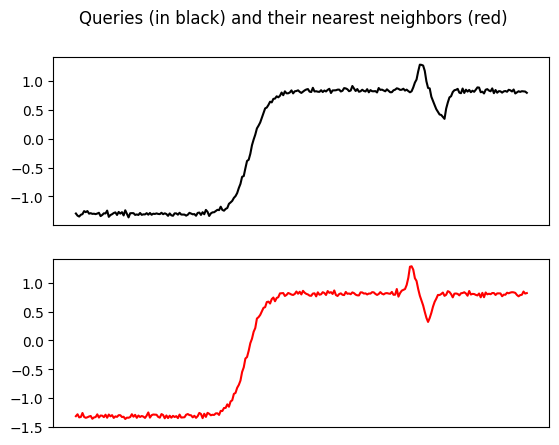

In [8]:
# Author: Romain Tavenard
# License: BSD 3 clause

import numpy
import matplotlib.pyplot as plt

from tslearn.neighbors import KNeighborsTimeSeries
from tslearn.datasets import CachedDatasets

seed = 0
numpy.random.seed(seed)
X_train, y_train, X_test, y_test = CachedDatasets().load_dataset("Trace")

n_queries = 1
n_neighbors = 1

knn = KNeighborsTimeSeries(n_neighbors=n_neighbors)
knn.fit(X_train)
ind = knn.kneighbors(X_test[:n_queries], return_distance=False)

plt.figure()
for idx_ts in range(n_queries):
    plt.subplot(n_neighbors + 1, n_queries, idx_ts + 1)
    plt.plot(X_test[idx_ts].ravel(), "k-")
    plt.xticks([])
    for rank_nn in range(n_neighbors):
        plt.subplot(n_neighbors + 1, n_queries,
                    idx_ts + (n_queries * (rank_nn + 1)) + 1)
        plt.plot(X_train[ind[idx_ts, rank_nn]].ravel(), "r-")
        plt.xticks([])


plt.suptitle("Queries (in black) and their nearest neighbors (red)")
plt.show()

In [9]:
X_train

array([[[ 0.54407],
        [ 0.65786],
        [ 0.61124],
        ...,
        [ 0.60377],
        [ 0.59633],
        [ 0.58322]],

       [[ 0.76643],
        [ 0.62463],
        [ 0.74225],
        ...,
        [ 0.72218],
        [ 0.66786],
        [ 0.72445]],

       [[-2.045  ],
        [-2.0917 ],
        [-2.0776 ],
        ...,
        [ 0.52429],
        [ 0.54742],
        [ 0.57056]],

       ...,

       [[-1.2657 ],
        [-1.2381 ],
        [-1.2569 ],
        ...,
        [ 0.90231],
        [ 0.87317],
        [ 0.84577]],

       [[ 0.67424],
        [ 0.6995 ],
        [ 0.72477],
        ...,
        [ 0.68093],
        [ 0.61272],
        [ 0.6502 ]],

       [[ 0.76816],
        [ 0.71678],
        [ 0.76064],
        ...,
        [ 0.76741],
        [ 0.75562],
        [ 0.67906]]], shape=(100, 275, 1))